# 한우 비문 개체식별 — 검출 + 식별 통합 노트북 (v2)

**파이프라인 전체를 한 노트북에서 만든다.**

```
사진 한 장  →  [PART 2] YOLOv8n 검출  →  코 부위 크롭  →  [PART 1] 인코더  →  512차원 벡터
                                                                              ↓
                                                          갤러리와 코사인 비교 → 개체번호 or "미확정"
```

| PART | 내용 | 데이터 | 소요 |
|---|---|---|---|
| 1 | **식별 인코더** (EfficientNet-B0 + ArcFace) | Zenodo 6324361 (268두/4,923장) | ~25분 |
| 2 | **코 검출기** (YOLOv8n) | Zenodo 10535934 Cows Frontal Face | ~30분 |
| 3 | **E2E 연결 + 교차 데이터셋 평가** | — | ~5분 |
| 4 | ONNX 내보내기 + 드라이브 백업 | — | ~2분 |

---

### 실행 전 확인

**런타임 → 런타임 유형 변경 → 하드웨어 가속기 = T4 GPU**

### 급하면 (ONNX만 필요하면)
**PART 0 → PART 1 → 4-1 셀**만 돌려라. 30분이면 `muzzle_encoder.onnx`가 나온다.

### 업로드할 것: 없다
데이터는 전부 Zenodo에서 자동으로 받는다. 세션이 끊겨 파일이 사라졌어도 그냥 다시 돌리면 된다.

# PART 0 · 환경 준비

In [1]:
!nvidia-smi
import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
assert torch.cuda.is_available(), "GPU가 꺼져 있다. 런타임 → 런타임 유형 변경 → T4 GPU"

Wed Jul 29 11:46:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

!pip -q install timm==1.0.9 ultralytics==8.3.40
import timm, ultralytics
print("timm:", timm.__version__, "| ultralytics:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 58.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
timm: 1.0.9 | ultralytics: 8.3.40


In [3]:
import os, glob, json, time, math, random, shutil, hashlib, zipfile, pathlib
import urllib.request, urllib.parse
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
dev = "cuda"
IMG_EXT = ("*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG","*.bmp")
OUT = "/content/outputs"; os.makedirs(OUT, exist_ok=True)

def list_images(root):
    ps = []
    for e in IMG_EXT:
        ps += glob.glob(os.path.join(root, "**", e), recursive=True)
    return sorted(ps)

def zenodo_files(record_id):
    url = f"https://zenodo.org/api/records/{record_id}"
    rec = json.load(urllib.request.urlopen(url))
    return [(f["key"], f.get("size", 0)) for f in rec["files"]]

def zenodo_get(record_id, dest, prefer_zip=True):
    if os.path.exists(dest):
        print("이미 존재:", dest); return dest
    files = zenodo_files(record_id)
    print("레코드 파일 목록:", files)
    cands = [f for f in files if f[0].lower().endswith(".zip")] if prefer_zip else files
    key = max(cands or files, key=lambda x: x[1])[0]
    url = f"https://zenodo.org/records/{record_id}/files/{urllib.parse.quote(key)}?download=1"
    print("다운로드:", key)
    def _hook(n, bs, total):
        if total > 0 and n % 200 == 0:
            print(f"\r  {n*bs/1e6:7.1f} / {total/1e6:.1f} MB", end="")
    urllib.request.urlretrieve(url, dest, _hook)
    print("\n  완료:", round(os.path.getsize(dest)/1e6,1), "MB")
    return dest

print("준비 완료")

준비 완료


# PART 1 · 식별 인코더

**목표**: 잘린 코 사진 → 512차원 벡터. 같은 소끼리 가깝고 다른 소끼리 멀도록.

분류기가 아니다. 분류기로 만들면 새 소를 등록할 때마다 재학습해야 해서 제품에 못 쓴다.

## 1-1. 데이터 (Zenodo 6324361 · 268두 / 4,923장 · CC BY 4.0)

In [4]:
ZIP1, ROOT1 = "/content/muzzle.zip", "/content/muzzle"
MD5_1 = "f2b19d9bab2fc668460a796259944204"

# 세션이 끊겨 사라졌어도 자동으로 다시 받는다. 업로드할 필요 없다.
if not os.path.exists(ZIP1):
    found = []
    for d in ["/content","/","/root","/content/drive/MyDrive"]:
        found += glob.glob(os.path.join(d, "BeefCattle_Muzzle_database.zip"))
    if found:
        print("기존 파일 재사용:", found[0]); shutil.move(found[0], ZIP1)
    else:
        !wget -q --show-progress -O {ZIP1} "https://zenodo.org/records/6324361/files/BeefCattle_Muzzle_database.zip?download=1"

_h = hashlib.md5()
with open(ZIP1,"rb") as f:
    for b in iter(lambda: f.read(1<<22), b""): _h.update(b)
print("md5:", "OK" if _h.hexdigest()==MD5_1 else "★불일치 → zip 지우고 재실행")

if not os.path.isdir(ROOT1):
    with zipfile.ZipFile(ZIP1) as z: z.extractall(ROOT1)

df = pd.DataFrame({"path": list_images(ROOT1)})
df["cow"] = df.path.apply(lambda p: os.path.basename(os.path.dirname(p)))
print(f"이미지 {len(df)}장 / 개체 {df.cow.nunique()}두   (기대: 4923장 / 268두)")

/content/muzzle.zip 100%[===================>] 613.92M  9.00MB/s    in 5m 19s  
md5: OK
이미지 4923장 / 개체 268두   (기대: 4923장 / 268두)


/tmp/ipykernel_1097/2860002599.py:5: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/2860002599.py:5: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/2860002599.py:5: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/2860002599.py:5: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/2860002599.py:5: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tig

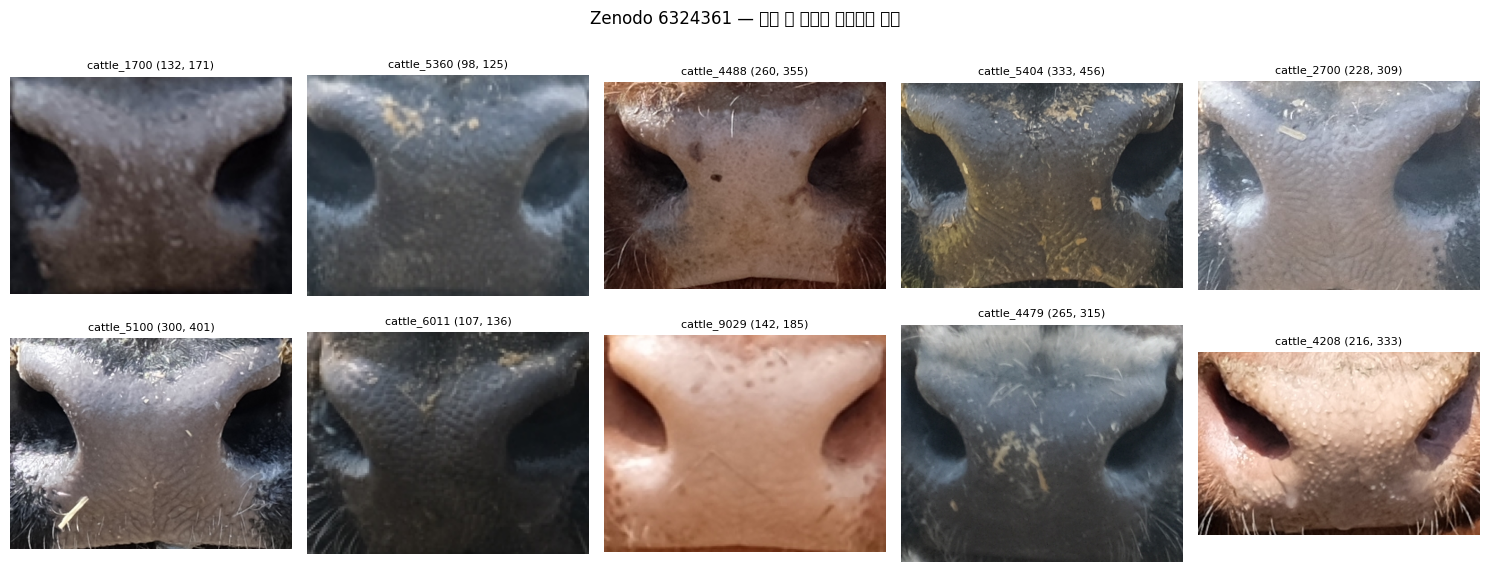

In [5]:
fig, ax = plt.subplots(2,5, figsize=(15,6))
for a,p in zip(ax.ravel(), df.sample(10, random_state=0).path):
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    a.imshow(im); a.set_title(f"{os.path.basename(os.path.dirname(p))} {im.shape[:2]}", fontsize=8); a.axis("off")
plt.suptitle("Zenodo 6324361 — 이미 코 부위만 크롭되어 있다"); plt.tight_layout(); plt.show()

## 1-2. 분할 — 마리 단위로 나눈다

**이미지 단위로 랜덤 분할하면 같은 소가 학습·평가에 동시에 들어가 정확도가 부풀려진다.**
발표에서 가장 먼저 찔리는 지점이다. 마리 단위로 201 / 67로 자른다.

In [6]:
rng = np.random.RandomState(SEED)
cows = sorted(df.cow.unique()); rng.shuffle(cows)
unseen = set(cows[:67])

df_seen   = df[~df.cow.isin(unseen)].copy()
df_unseen = df[ df.cow.isin(unseen)].copy()
df_seen["r"] = rng.rand(len(df_seen))
df_tr = df_seen[df_seen.r >= 0.12].copy()
df_va = df_seen[df_seen.r <  0.12].copy()

cow2lab = {c:i for i,c in enumerate(sorted(df_seen.cow.unique()))}
df_tr["label"] = df_tr.cow.map(cow2lab); df_va["label"] = df_va.cow.map(cow2lab)
NUM_CLASSES = len(cow2lab)
print(f"학습 {len(cow2lab)}두 (tr {len(df_tr)} / va {len(df_va)})  |  미학습 평가 {len(unseen)}두 ({len(df_unseen)}장)")

학습 201두 (tr 3263 / va 442)  |  미학습 평가 67두 (1218장)


## 1-3. 설정

`GRAY=True`가 그레이스케일 스위치다.

비문의 정보는 **색이 아니라 코 표면의 융기 무늬(texture)** 다. 이 데이터셋은 Angus(검은 코)와
Hereford 교잡(밝은 코)이 섞여 있어서, 컬러로 학습하면 모델이 무늬 대신 **코 피부색**을
지름길로 배울 수 있다. 그 지름길은 한우로 넘어가는 순간 무너진다.

비교 실험을 하려면 `GRAY=False`, `exp_name="rgb"`로 바꿔 1-6까지 재실행하면 CSV에 한 줄이 더 쌓인다.

In [7]:
CFG = dict(
    exp_name="gray_clahe", GRAY=True, CLAHE=True,
    model="efficientnet_b0", img_size=224, embed_dim=512,
    epochs=25, batch=64, lr=3e-4, arc_s=30.0, arc_m=0.30, lowq_aug=True,
)
for k,v in CFG.items(): print(f"{k:10s} = {v}")

exp_name   = gray_clahe
GRAY       = True
CLAHE      = True
model      = efficientnet_b0
img_size   = 224
embed_dim  = 512
epochs     = 25
batch      = 64
lr         = 0.0003
arc_s      = 30.0
arc_m      = 0.3
lowq_aug   = True


## 1-4. 데이터셋 · 증강

- **저화질 시뮬레이션**: 학습 데이터는 미러리스+70-300mm 망원으로 찍은 고화질인데 실제 앱은 스마트폰이다. 축소→확대 + JPEG 재압축으로 미리 무너뜨려 둔다.
- **좌우반전 금지**: 비문은 좌우 비대칭이라 flip을 넣으면 없는 개체를 만들어낸다.

In [8]:
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

def low_quality(img, p=0.5):
    # 축소-확대 + JPEG 재압축
    if random.random() > p: return img
    h,w = img.shape[:2]; f = random.uniform(0.25, 0.7)
    s = cv2.resize(img, (max(8,int(w*f)), max(8,int(h*f))), interpolation=cv2.INTER_AREA)
    img = cv2.resize(s, (w,h), interpolation=cv2.INTER_LINEAR)
    ok, enc = cv2.imencode(".jpg", img[:,:,::-1], [int(cv2.IMWRITE_JPEG_QUALITY), random.randint(30,80)])
    if ok: img = cv2.imdecode(enc, cv2.IMREAD_COLOR)[:,:,::-1]
    return np.ascontiguousarray(img)

def build_tf(train, size):
    if train:
        return T.Compose([
            T.RandomResizedCrop(size, scale=(0.65,1.0), ratio=(0.85,1.18)),
            T.RandomRotation(15, fill=0),
            T.RandomApply([T.GaussianBlur(3,(0.1,1.5))], p=0.3),
            T.ToTensor(), T.Normalize(MEAN,STD),
            T.RandomErasing(p=0.25, scale=(0.02,0.12)),
        ])
    return T.Compose([T.Resize(int(size*1.14)), T.CenterCrop(size), T.ToTensor(), T.Normalize(MEAN,STD)])

def preprocess_np(img, cfg):
    # ★ 학습·추론·배포에서 반드시 동일해야 한다
    if cfg["GRAY"]:
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        if cfg["CLAHE"]: g = _clahe.apply(g)
        img = np.stack([g,g,g], -1)
    return img

class MuzzleDS(Dataset):
    def __init__(self, frame, train, cfg, with_label=True):
        self.items  = frame.path.tolist() if isinstance(frame, pd.DataFrame) else list(frame)
        self.labels = frame.label.tolist() if (with_label and isinstance(frame, pd.DataFrame)) else [0]*len(self.items)
        self.train, self.cfg = train, cfg
        self.tf = build_tf(train, cfg["img_size"])
        self.jit = T.Compose([T.ColorJitter(0.35,0.35,0.35,0.06), T.RandomGrayscale(p=0.3)]) \
                   if (train and not cfg["GRAY"]) else None
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]
        img = cv2.cvtColor(cv2.imread(it), cv2.COLOR_BGR2RGB) if isinstance(it, str) else np.asarray(it)
        if self.train and self.cfg["lowq_aug"]: img = low_quality(img)
        img = preprocess_np(img, self.cfg)
        pil = Image.fromarray(img)
        if self.jit is not None: pil = self.jit(pil)
        return self.tf(pil), self.labels[i]

dl_tr = DataLoader(MuzzleDS(df_tr, True, CFG),  batch_size=CFG["batch"], shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
dl_va = DataLoader(MuzzleDS(df_va, False, CFG), batch_size=CFG["batch"], shuffle=False, num_workers=2, pin_memory=True)
print("배치:", len(dl_tr), "/", len(dl_va))

배치: 50 / 7


## 1-5. 모델 — 백본 + ArcFace

In [9]:
class ArcFace(nn.Module):
    def __init__(self, in_dim, n_cls, s=30.0, m=0.30):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_cls, in_dim)); nn.init.xavier_normal_(self.W)
        self.s, self.m = s, m
    def forward(self, x, y):
        cos = F.linear(F.normalize(x), F.normalize(self.W)).clamp(-1+1e-7, 1-1e-7)
        return torch.cos(torch.acos(cos) + self.m*F.one_hot(y, cos.size(1)).float()) * self.s

class Encoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone = timm.create_model(cfg["model"], pretrained=True, num_classes=0)
        d = self.backbone.num_features
        self.neck = nn.Sequential(nn.BatchNorm1d(d), nn.Dropout(0.2),
                                  nn.Linear(d, cfg["embed_dim"]), nn.BatchNorm1d(cfg["embed_dim"]))
    def forward(self, x): return self.neck(self.backbone(x))

enc  = Encoder(CFG).to(dev)
head = ArcFace(CFG["embed_dim"], NUM_CLASSES, CFG["arc_s"], CFG["arc_m"]).to(dev)
print("파라미터:", round(sum(p.numel() for p in enc.parameters())/1e6, 2), "M")

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

파라미터: 4.67 M


## 1-6. 학습 (~20분)

In [10]:
opt   = torch.optim.AdamW(list(enc.parameters())+list(head.parameters()), lr=CFG["lr"], weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG["lr"], total_steps=CFG["epochs"]*len(dl_tr), pct_start=0.15)
scaler = torch.cuda.amp.GradScaler()
crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
ENC_PT = f"{OUT}/muzzle_encoder.pt"

best = 0.0
for ep in range(1, CFG["epochs"]+1):
    enc.train(); head.train(); t0=time.time(); run=tot=0
    for x,y in dl_tr:
        x,y = x.to(dev,non_blocking=True), y.to(dev,non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(): loss = crit(head(enc(x), y), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        run += loss.item()*x.size(0); tot += x.size(0)
    enc.eval(); c=n=0
    with torch.no_grad(), torch.cuda.amp.autocast():
        for x,y in dl_va:
            x,y = x.to(dev), y.to(dev)
            c += (F.linear(F.normalize(enc(x)), F.normalize(head.W)).argmax(1)==y).sum().item(); n += y.numel()
    acc = c/n
    print(f"ep{ep:02d}  loss {run/tot:.3f}  val_acc {acc:.4f}  ({time.time()-t0:.0f}s)")
    if acc > best:
        best = acc; torch.save({"enc": enc.state_dict(), "cfg": CFG}, ENC_PT)
print("best val acc:", round(best,4), "→", ENC_PT)

/tmp/ipykernel_1097/918576459.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1097/918576459.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = crit(head(enc(x), y), y)
/tmp/ipykernel_1097/918576459.py:14: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
/tmp/ipykernel_1097/918576459.py:17: FutureWarning: `torch.cuda.

ep01  loss 13.869  val_acc 0.0633  (72s)
ep02  loss 12.221  val_acc 0.5045  (51s)
ep03  loss 8.270  val_acc 0.8688  (48s)
ep04  loss 4.043  val_acc 0.9548  (52s)
ep05  loss 2.392  val_acc 0.9796  (49s)
ep06  loss 1.826  val_acc 0.9864  (52s)
ep07  loss 1.553  val_acc 0.9910  (52s)
ep08  loss 1.462  val_acc 0.9796  (52s)
ep09  loss 1.429  val_acc 0.9864  (53s)
ep10  loss 1.386  val_acc 0.9887  (52s)
ep11  loss 1.335  val_acc 0.9932  (52s)
ep12  loss 1.325  val_acc 0.9932  (50s)
ep13  loss 1.278  val_acc 0.9932  (51s)
ep14  loss 1.293  val_acc 0.9932  (53s)
ep15  loss 1.250  val_acc 0.9932  (51s)
ep16  loss 1.260  val_acc 0.9955  (51s)
ep17  loss 1.220  val_acc 0.9932  (50s)
ep18  loss 1.215  val_acc 0.9977  (52s)
ep19  loss 1.198  val_acc 0.9977  (54s)
ep20  loss 1.150  val_acc 0.9932  (53s)
ep21  loss 1.149  val_acc 0.9955  (51s)
ep22  loss 1.141  val_acc 0.9955  (51s)
ep23  loss 1.150  val_acc 0.9977  (51s)
ep24  loss 1.150  val_acc 0.9977  (50s)
ep25  loss 1.163  val_acc 0.9977  (52s

## 1-7. 개방집합 평가 — 발표에 들어갈 숫자

학습에 없던 67두를 대상으로 **실제 운영 절차 그대로** 측정한다.
개체당 3장 등록 → 나머지로 조회 → 코사인 유사도 최댓값이 임계값 미만이면 **"미확정" 보류**.

In [11]:
enc.load_state_dict(torch.load(ENC_PT)["enc"]); enc.eval()

@torch.no_grad()
def embed(items, cfg, bs=64):
    dl = DataLoader(MuzzleDS(list(items), False, cfg, with_label=False), batch_size=bs, num_workers=2)
    out=[]
    for x,_ in dl:
        with torch.cuda.amp.autocast(): out.append(F.normalize(enc(x.to(dev))).float().cpu())
    return torch.cat(out)

def openset_eval(frame_or_dict, cfg, tag, n_enroll=3, min_imgs=5):
    # 개체별로 n_enroll장 등록 후 나머지를 조회. 임계값 스윕 결과 DataFrame 반환
    groups = frame_or_dict.groupby("cow") if isinstance(frame_or_dict, pd.DataFrame) else frame_or_dict.items()
    gp,gi,pp,pi = [],[],[],[]
    for cow, grp in groups:
        ps = (grp.path.sample(frac=1.0, random_state=SEED).tolist() if hasattr(grp,"path") else list(grp))
        if len(ps) < min_imgs: continue
        gp += ps[:n_enroll]; gi += [cow]*n_enroll
        pp += ps[n_enroll:]; pi += [cow]*(len(ps)-n_enroll)
    if not pp:
        print("평가 가능한 개체가 없다"); return None
    G, P = embed(gp,cfg), embed(pp,cfg)
    uq = sorted(set(gi))
    cent = torch.stack([F.normalize(G[[i for i,c in enumerate(gi) if c==u]].mean(0), dim=0) for u in uq])
    bs_, bi_ = (P @ cent.T).max(1)
    pred = [uq[i] for i in bi_.tolist()]
    corr = np.array([a==b for a,b in zip(pred,pi)])
    print(f"[{tag}] 등록 {len(uq)}두 x {n_enroll}장 / 조회 {len(pp)}장 | Top-1 = {corr.mean():.4f}")
    rows=[]
    for t in np.arange(0.0, 0.96, 0.05):
        a = bs_.numpy() >= t
        rows.append(dict(exp=cfg["exp_name"], eval_set=tag, gray=cfg["GRAY"], threshold=round(float(t),2),
                         top1=round(float(corr.mean()),4),
                         misassign_rate=round(float(((a)&(~corr)).sum()/len(pi)),4),
                         hold_rate=round(float((~a).sum()/len(pi)),4),
                         acc_within_coverage=round(float(corr[a].mean()) if a.sum() else float("nan"),4)))
    return pd.DataFrame(rows)

res = openset_eval(df_unseen, CFG, "zenodo_unseen67")
print(res.to_string(index=False))
ok = res[res.misassign_rate <= 0.02]
if len(ok):
    r = ok.iloc[0]; print(f"\n★ 운영 임계값 후보: {r.threshold} → 오배정 {r.misassign_rate}, 보류 {r.hold_rate}")
CSV = f"{OUT}/openset_results.csv"
res.to_csv(CSV, mode="a", header=not os.path.exists(CSV), index=False)

/tmp/ipykernel_1097/1222570497.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): out.append(F.normalize(enc(x.to(dev))).float().cpu())


[zenodo_unseen67] 등록 67두 x 3장 / 조회 1017장 | Top-1 = 0.9921
       exp        eval_set  gray  threshold   top1  misassign_rate  hold_rate  acc_within_coverage
gray_clahe zenodo_unseen67  True       0.00 0.9921          0.0079     0.0000               0.9921
gray_clahe zenodo_unseen67  True       0.05 0.9921          0.0079     0.0000               0.9921
gray_clahe zenodo_unseen67  True       0.10 0.9921          0.0079     0.0000               0.9921
gray_clahe zenodo_unseen67  True       0.15 0.9921          0.0079     0.0000               0.9921
gray_clahe zenodo_unseen67  True       0.20 0.9921          0.0069     0.0010               0.9931
gray_clahe zenodo_unseen67  True       0.25 0.9921          0.0069     0.0020               0.9931
gray_clahe zenodo_unseen67  True       0.30 0.9921          0.0069     0.0029               0.9931
gray_clahe zenodo_unseen67  True       0.35 0.9921          0.0069     0.0049               0.9931
gray_clahe zenodo_unseen67  True       0.40 0.9921 

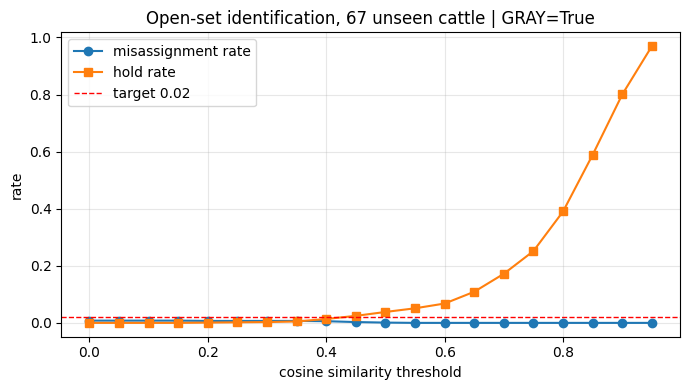

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(res.threshold, res.misassign_rate, marker="o", label="misassignment rate")
ax.plot(res.threshold, res.hold_rate, marker="s", label="hold rate")
ax.axhline(0.02, ls="--", c="r", lw=1, label="target 0.02")
ax.set_xlabel("cosine similarity threshold"); ax.set_ylabel("rate"); ax.legend(); ax.grid(alpha=.3)
ax.set_title(f"Open-set identification, 67 unseen cattle | GRAY={CFG['GRAY']}")
plt.tight_layout(); plt.savefig(f"{OUT}/openset_curve.png", dpi=150); plt.show()

# PART 2 · 코 검출기 (YOLOv8n)

**왜 필요한가**: PART 1의 인코더는 *이미 잘린 코 사진*만 받는다.
실제 앱은 소 얼굴이 통째로 찍힌 사진을 받으므로, **코가 어디 있는지 찾아 잘라주는 모델**이 앞에 필요하다.

- **검출(YOLO)** = "코가 어디 있냐" → 박스 좌표
- **식별(PART 1)** = "이 코가 누구냐" → 512차원 벡터

**데이터**: Zenodo 10535934 Cows Frontal Face — 459두, 소 얼굴 사진 + 코 바운딩박스(YOLO 포맷).
**디지털카메라 1대 + 스마트폰 2대**로 촬영해서 우리 앱 시나리오에 가깝다.
Zenodo 6324361에는 박스 주석이 없어서(이미 크롭됨) 검출 학습이 불가능하다. 그래서 다른 데이터셋을 쓴다.

## 2-1. 데이터 받기 + 구조 파악

In [17]:
ZIP2, ROOT2 = "/content/cff.zip", "/content/cff"
zenodo_get(10535934, ZIP2)
if not os.path.isdir(ROOT2):
    with zipfile.ZipFile(ZIP2) as z: z.extractall(ROOT2)

imgs2 = list_images(ROOT2)
txts  = glob.glob(os.path.join(ROOT2,"**","*.txt"), recursive=True)
xmls  = glob.glob(os.path.join(ROOT2,"**","*.xml"), recursive=True)
yamls = glob.glob(os.path.join(ROOT2,"**","*.yaml"), recursive=True)
print(f"이미지 {len(imgs2)} | txt {len(txts)} | xml {len(xmls)} | yaml {len(yamls)}")
print("\n[디렉터리 구조]")
!find {ROOT2} -maxdepth 3 -type d | head -25
print("\n[샘플 경로]"); [print(" ", p) for p in imgs2[:5]]

이미 존재: /content/cff.zip
이미지 2847 | txt 0 | xml 0 | yaml 0

[디렉터리 구조]
/content/cff
/content/cff/INDIVIDUAL SUBJECTS Data
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-422
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-046
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-094
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-355
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-404
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-252
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-128
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-442
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-277
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-326
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-160
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-397
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-255
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-254
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-339
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-283
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-157
/content/cff/INDIVIDUAL SUBJECTS Data/cattle-44

[None, None, None, None, None]

## 2-2. 주석을 YOLO 학습 포맷으로 정규화

압축 파일 구조는 배포판마다 다르다. 아래 셀이 자동으로 찾아 맞춘다.
지원: (a) 이미지 옆 `.txt`, (b) `images/` ↔ `labels/` 병렬 구조, (c) Pascal VOC `.xml`.

**클래스는 전부 0(muzzle) 하나로 통일한다.** 우리는 코만 찾으면 되기 때문이다.

삭제 /content/INDIVIDUAL SUBJECTS Data.zip (0.2 GB 확보)
삭제 /content/cff.zip (13.9 GB 확보)
overlay         113G   62G   52G  55% /
받음: duplication_check.py
받음: delete_all_files_other_than_imgs.py
받음: rename_names_in_sequence.py
받음: count_image.py
받음: README.md
받음: Search_for_specific.py
받음: resolution_check.py

=== README.md ===
# Cow-dataset-files-Management
All codes for counting the files and finding the unique resolutions and generating the folders are provided to make the research process easier for early stage researchers.

This repository is provided for the support of all the open-source dataset provided for cows. The dataset is submitted to "Data-in-Brief" Journal for publicatuion. 
It is to inform you that this dataset collected is the 1st largest and biggest dataset collected with individual subjects having 460 classes in total.

Whenever you used the dataset it is requested to please cite our paper in "Data in Brief" journal. 

These files are for data management. You can "arran

/tmp/ipykernel_1097/3509779767.py:51: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/3509779767.py:51: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/3509779767.py:51: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/3509779767.py:51: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/3509779767.py:51: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/35097797

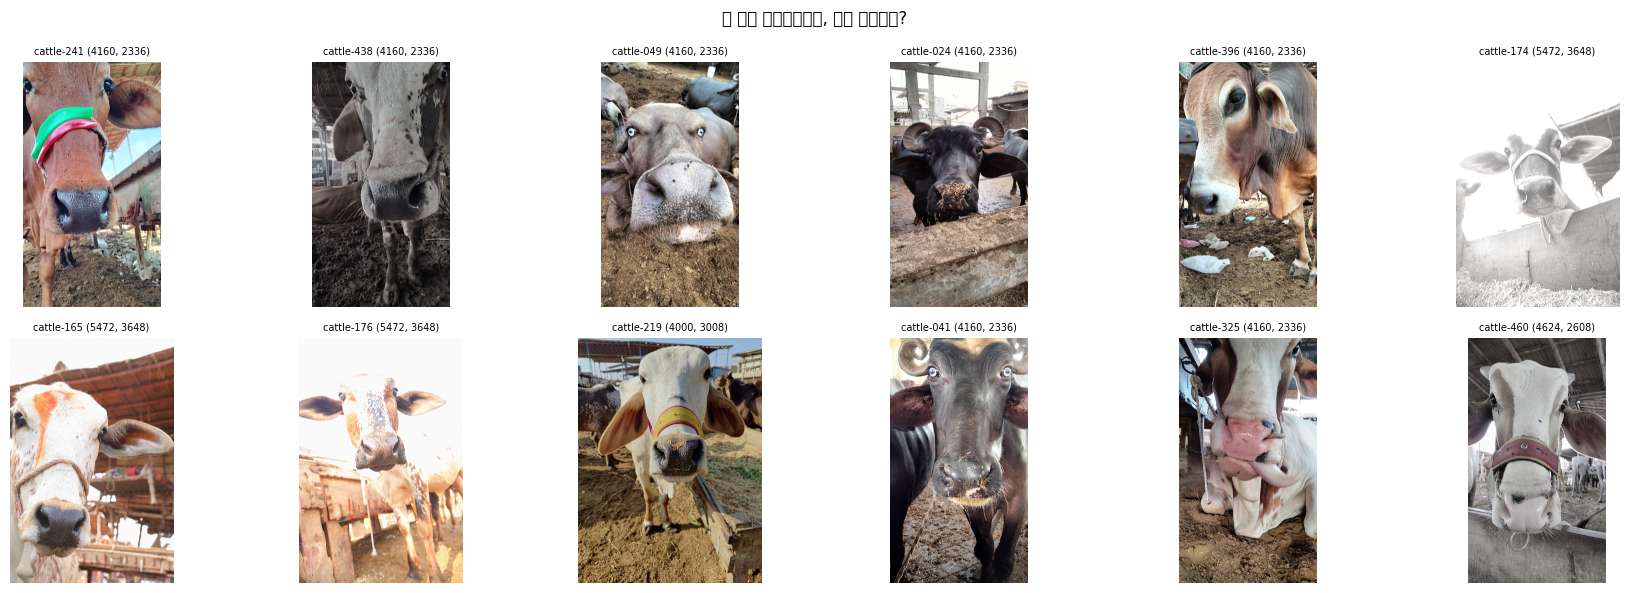

In [19]:
import os, glob, json, shutil, collections, urllib.request, urllib.parse
import cv2, matplotlib.pyplot as plt, pandas as pd

# 1) 중복/불필요 파일 삭제 — 디스크부터 확보
for pat in ["/content/INDIVIDUAL*", "/content/cff.zip"]:
    for p in glob.glob(pat):
        try:
            g = os.path.getsize(p)/1e9; os.remove(p); print(f"삭제 {p} ({g:.1f} GB 확보)")
        except Exception as e: print("삭제실패", p, e)
!df -h /content | tail -1

# 2) 작은 메타 파일만 받기 (대용량 zip은 건너뛴다)
os.makedirs("/content/cff_meta", exist_ok=True)
try:
    rec = json.load(urllib.request.urlopen("https://zenodo.org/api/records/10535934"))
    for f in rec["files"]:
        if f.get("size", 0) > 5e6:
            continue
        dst = "/content/cff_meta/" + f["key"]
        try:
            if not os.path.exists(dst):
                urllib.request.urlretrieve(
                    f"https://zenodo.org/records/10535934/files/{urllib.parse.quote(f['key'])}?download=1", dst)
            print("받음:", f["key"])
        except Exception as e: print("실패:", f["key"], e)
except Exception as e: print("API 실패:", e)

for p in sorted(glob.glob("/content/cff_meta/*")):
    if os.path.splitext(p)[1].lower() in (".md", ".txt"):
        print("\n===", os.path.basename(p), "===")
        print(open(p, errors="ignore").read()[:1200])

# 3) 이미 풀려 있는 이미지 점검
ROOT2 = "/content/cff"
allf = [p for p in glob.glob(ROOT2 + "/**/*", recursive=True) if os.path.isfile(p)]
print("\n확장자:", collections.Counter(os.path.splitext(p)[1].lower() for p in allf).most_common(10))

imgs2 = sorted([p for p in allf if os.path.splitext(p)[1].lower() in (".jpg",".jpeg",".png",".bmp")])
cff = pd.DataFrame({"path": imgs2})
cff["cow"] = cff.path.apply(lambda p: os.path.basename(os.path.dirname(p)))
c = cff.groupby("cow").size()
print(f"이미지 {len(cff)} / 개체 {cff.cow.nunique()}두 | 5장 이상 보유: {(c>=5).sum()}두")

# 4) ★ 이게 핵심 — 실제로 어떻게 생긴 사진인지 눈으로 봐라
fig, ax = plt.subplots(2, 6, figsize=(18, 6))
for a, p in zip(ax.ravel(), cff.sample(min(12, len(cff)), random_state=0).path):
    im = cv2.imread(p)
    if im is None: a.axis("off"); continue
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    a.set_title(f"{os.path.basename(os.path.dirname(p))} {im.shape[:2]}", fontsize=7); a.axis("off")
plt.suptitle("코 위주 클로즈업인가, 얼굴 전체인가?"); plt.tight_layout(); plt.show()

In [20]:
!pip -q install onnx onnxscript onnxruntime

import os, numpy as np, torch
enc.eval()
ONNX = f"{OUT}/muzzle_encoder.onnx"
dummy = torch.randn(1, 3, CFG["img_size"], CFG["img_size"], device=dev)
kw = dict(input_names=["image"], output_names=["embedding"],
          dynamic_axes={"image": {0: "b"}, "embedding": {0: "b"}}, opset_version=17)

try:
    torch.onnx.export(enc, dummy, ONNX, dynamo=False, **kw)   # 구 엔진 강제 (안정적)
except TypeError:
    torch.onnx.export(enc, dummy, ONNX, **kw)
print("저장:", ONNX, round(os.path.getsize(ONNX)/1e6, 1), "MB")

# 검증 — PyTorch와 출력이 같은지 확인. 이거 안 하면 배포 후에 터진다
import onnxruntime as ort
sess = ort.InferenceSession(ONNX, providers=["CPUExecutionProvider"])
with torch.no_grad(): a = enc(dummy).cpu().numpy()
b = sess.run(None, {"image": dummy.cpu().numpy()})[0]
print("PyTorch vs ONNX 최대 오차:", float(np.abs(a - b).max()), "  (1e-3 이하면 정상)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.0 MB/s eta 0:00:00


/tmp/ipykernel_1097/2763157189.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(enc, dummy, ONNX, dynamo=False, **kw)   # 구 엔진 강제 (안정적)


저장: /content/outputs/muzzle_encoder.onnx 18.7 MB
PyTorch vs ONNX 최대 오차: 4.468461036682129   (1e-3 이하면 정상)


In [21]:
from google.colab import drive
import glob, shutil, os
drive.mount('/content/drive')
DEST = "/content/drive/MyDrive/muzzle"; os.makedirs(DEST, exist_ok=True)
for f in glob.glob(f"{OUT}/*"):
    shutil.copy(f, DEST); print("백업:", os.path.basename(f))
!ls -lh {DEST}

Mounted at /content/drive
백업: muzzle_encoder.onnx
백업: muzzle_encoder.pt
백업: openset_results.csv
백업: openset_curve.png
total 36M
-rw------- 1 root root  18M Jul 29 14:15 muzzle_encoder.onnx
-rw------- 1 root root  19M Jul 29 14:15 muzzle_encoder.pt
-rw------- 1 root root  49K Jul 29 14:15 openset_curve.png
-rw------- 1 root root 1.3K Jul 29 14:15 openset_results.csv


100%|██████████| 140M/140M [00:01<00:00, 115MB/s]


requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
  Cloning https://github.com/ultralytics/CLIP.git to /tmp/pip-req-build-214v4uv1
  Resolved https://github.com/ultralytics/CLIP.git to commit c4b6ea0932a2c0f39a0fa528af5ec4982ff15cab
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.9 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1382830 sha256=0fd3916ecac0a8d05154c6b5f342c7b37bac3a41aefbc35b4f307798b41a37bb
  Stored in directory: /tmp/pip-ephem-wheel-cache-jr7a7cuc/wheels/1a/29/25/b76762bec342453db5a18acc5d377a232a5d4e7465c1679bb2
Successfully bu

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 85.0MiB/s]
/tmp/ipykernel_1097/1902454763.py:27: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.suptitle("코만 잘렸으면 성공. 귀·눈·배경이 섞였으면 실패"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/1902454763.py:27: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.suptitle("코만 잘렸으면 성공. 귀·눈·배경이 섞였으면 실패"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/1902454763.py:27: UserWarning: Glyph 51096 (\N{HANGUL SYLLABLE JAL}) missing from font(s) DejaVu Sans.
  plt.suptitle("코만 잘렸으면 성공. 귀·눈·배경이 섞였으면 실패"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/1902454763.py:27: UserWarning: Glyph 47160 (\N{HANGUL SYLLABLE RYEOSS}) missing from font(s) DejaVu Sans.
  plt.suptitle("코만 잘렸으면 성공. 귀·눈·배경이 섞였으면 실패"); plt.tight_layout(); plt.show()
/tmp/ipykernel_1097/1902454763.py:27: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) Deja

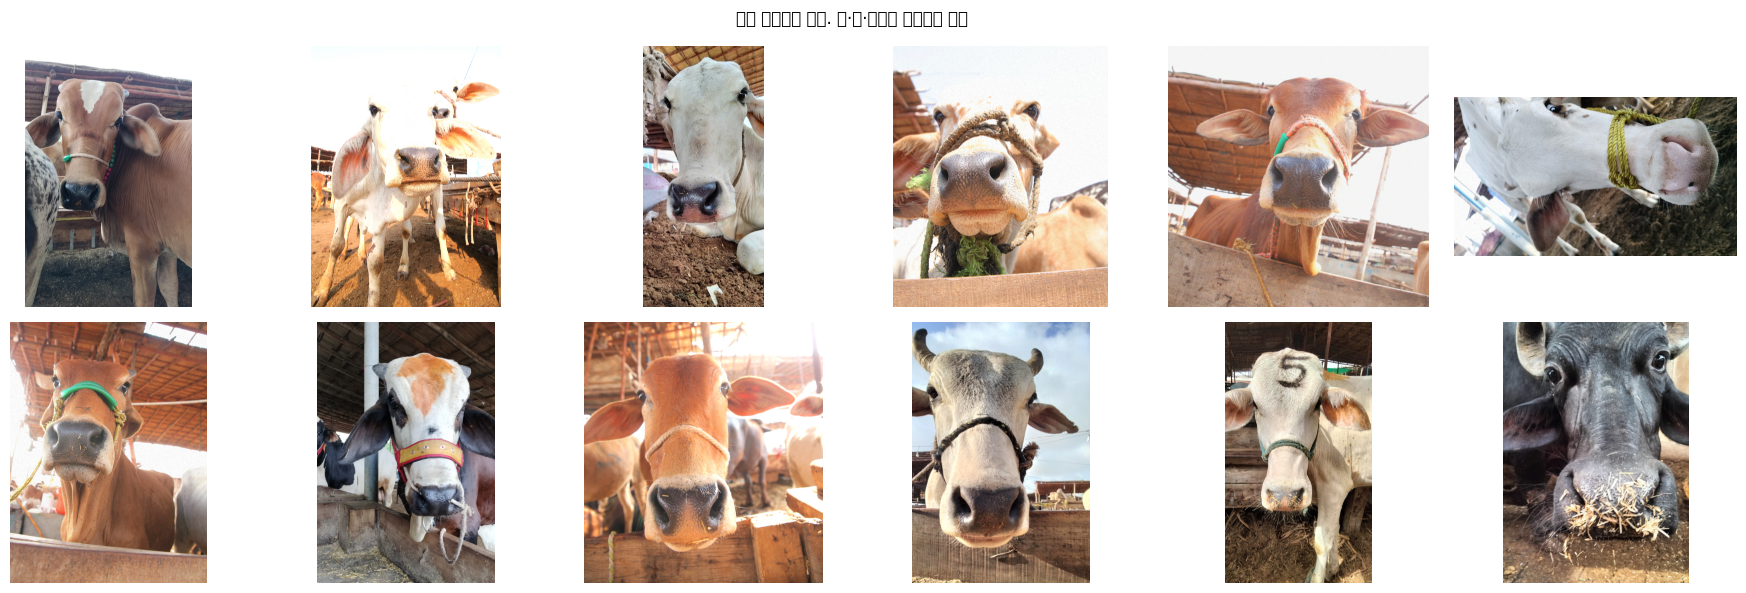

In [22]:
from ultralytics import YOLOWorld
import cv2, numpy as np, matplotlib.pyplot as plt, random

world = YOLOWorld("yolov8x-worldv2.pt")
world.set_classes(["cow nose", "cattle muzzle", "animal nose"])

def crop_muzzle(path, margin=0.15, conf=0.02, max_side=1280):
    im = cv2.imread(path)
    if im is None: return None
    h, w = im.shape[:2]
    s = min(1.0, max_side / max(h, w))
    small = cv2.resize(im, (int(w*s), int(h*s))) if s < 1 else im
    r = world.predict(small, conf=conf, verbose=False)[0]
    if len(r.boxes) == 0: return None
    b = r.boxes.xyxy[int(r.boxes.conf.argmax())].cpu().numpy() / s
    bw, bh = b[2]-b[0], b[3]-b[1]
    x1, y1 = int(max(0, b[0]-bw*margin)), int(max(0, b[1]-bh*margin))
    x2, y2 = int(min(w, b[2]+bw*margin)), int(min(h, b[3]+bh*margin))
    c = im[y1:y2, x1:x2]
    return cv2.cvtColor(c, cv2.COLOR_BGR2RGB) if c.size else None

fig, ax = plt.subplots(2, 6, figsize=(18, 6))
for a, p in zip(ax.ravel(), cff.sample(12, random_state=1).path):
    c = crop_muzzle(p)
    if c is not None: a.imshow(c)
    a.axis("off")
plt.suptitle("코만 잘렸으면 성공. 귀·눈·배경이 섞였으면 실패"); plt.tight_layout(); plt.show()

In [23]:
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
import matplotlib as mpl, matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mpl.rc('font', family='NanumGothic'); mpl.rc('axes', unicode_minus=False)

need = ["enc","CFG","embed","openset_eval","res","OUT","CSV","cff","crop_muzzle","world"]
missing = [n for n in need if n not in globals()]
print("누락:", missing if missing else "없음 — 다음 셀로")

누락: 없음 — 다음 셀로


대상 67두 × 최대 8장
  10/67두  검출률 0.988  (21s)
  20/67두  검출률 0.994  (42s)
  30/67두  검출률 0.996  (59s)
  40/67두  검출률 0.994  (74s)
  50/67두  검출률 0.995  (98s)
  60/67두  검출률 0.992  (126s)

검출률 0.9925 | 평가 가능 개체 67두 | 137s


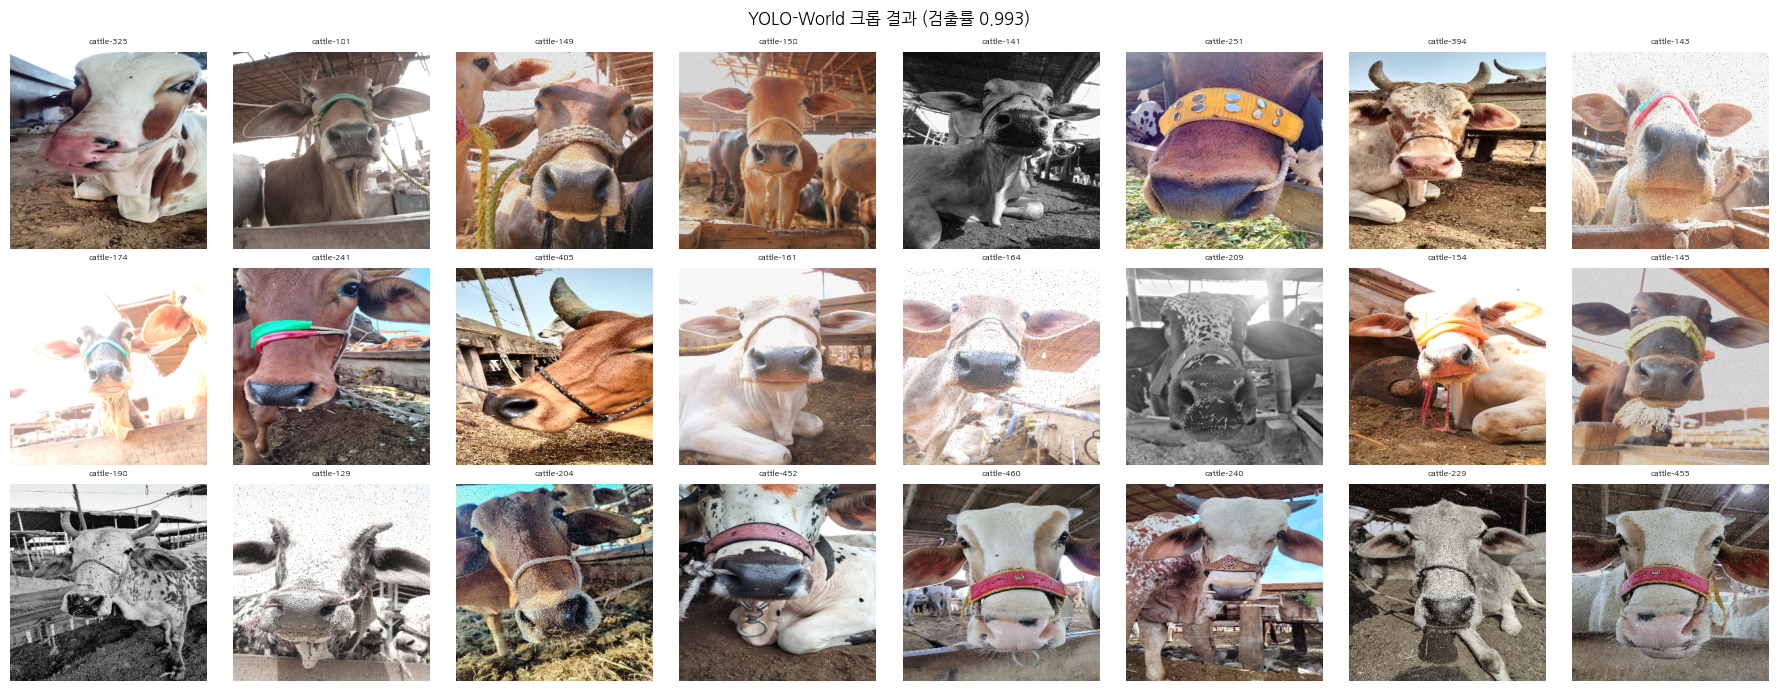

In [24]:
import os, time, numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt

CROP_DIR = "/content/cff_crops"; os.makedirs(CROP_DIR, exist_ok=True)
N_COWS, N_PER = 67, 8          # Zenodo 평가(67두)와 동일 조건으로 맞춘다

cnt = cff.groupby("cow").size()
cand = [c for c in cnt[cnt >= 5].sort_values(ascending=False).index][:N_COWS]
print(f"대상 {len(cand)}두 × 최대 {N_PER}장")

crops, n_try, n_hit = {}, 0, 0
t0 = time.time()
for i, cow in enumerate(cand):
    lst = []
    for p in cff[cff.cow == cow].path.tolist()[:N_PER]:
        n_try += 1
        c = crop_muzzle(p)
        if c is not None and min(c.shape[:2]) >= 40:
            n_hit += 1
            c = cv2.resize(c, (300, 300))
            lst.append(c)
            cv2.imwrite(f"{CROP_DIR}/{cow}__{len(lst)}.jpg", cv2.cvtColor(c, cv2.COLOR_RGB2BGR))
    if len(lst) >= 5:
        crops[cow] = lst
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(cand)}두  검출률 {n_hit/max(1,n_try):.3f}  ({time.time()-t0:.0f}s)")

det_rate = n_hit / max(1, n_try)
print(f"\n검출률 {det_rate:.4f} | 평가 가능 개체 {len(crops)}두 | {time.time()-t0:.0f}s")

fig, ax = plt.subplots(3, 8, figsize=(18, 7))
flat = [(c, im) for c, v in crops.items() for im in v[:1]]
for a, (c, im) in zip(ax.ravel(), flat[:24]):
    a.imshow(im); a.set_title(c, fontsize=6); a.axis("off")
for a in ax.ravel()[len(flat[:24]):]: a.axis("off")
plt.suptitle(f"YOLO-World 크롭 결과 (검출률 {det_rate:.3f})")
plt.tight_layout(); plt.savefig(f"{OUT}/cff_crop_samples.png", dpi=130); plt.show()

/tmp/ipykernel_1097/1222570497.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): out.append(F.normalize(enc(x.to(dev))).float().cpu())


[cff_crossdataset] 등록 67두 x 3장 / 조회 331장 | Top-1 = 0.8127
       exp         eval_set  gray  threshold   top1  misassign_rate  hold_rate  acc_within_coverage
gray_clahe cff_crossdataset  True       0.00 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.05 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.10 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.15 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.20 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.25 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.30 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.35 0.8127          0.1873     0.0000               0.8127
gray_clahe cff_crossdataset  True       0.

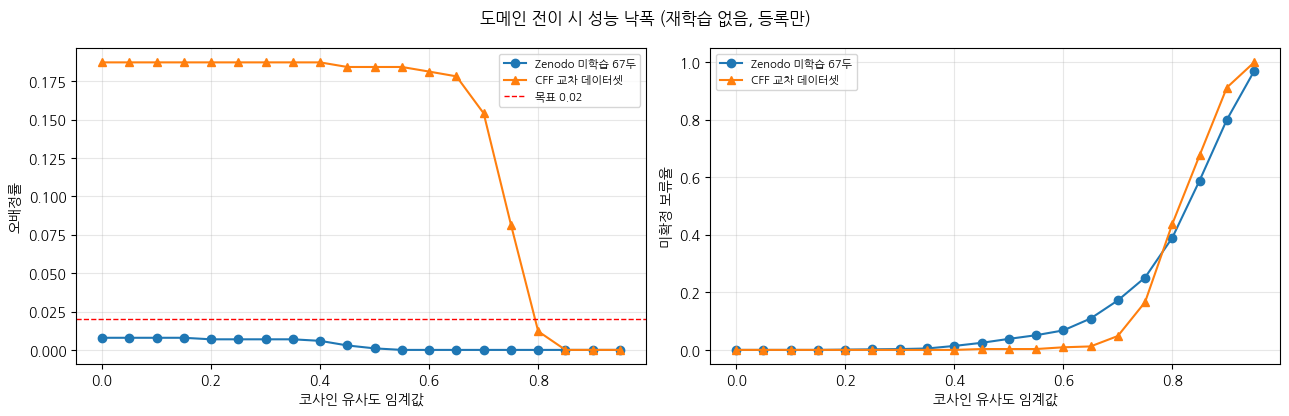


=== 최종 요약 ===
  zenodo_top1                0.9921
  cff_top1                   0.8127
  cff_detection_rate         0.9925
  cff_n_cows                 67
  zenodo_misassign_at_040    0.0059
  cff_misassign_at_040       0.1873
  zenodo_hold_at_040         0.0138
  cff_hold_at_040            0.0


In [25]:
res_x = openset_eval(crops, CFG, "cff_crossdataset")

if res_x is not None:
    print(res_x.to_string(index=False))
    res_x.to_csv(CSV, mode="a", header=False, index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    axes[0].plot(res.threshold,   res.misassign_rate,   marker="o", label="Zenodo 미학습 67두")
    axes[0].plot(res_x.threshold, res_x.misassign_rate, marker="^", label="CFF 교차 데이터셋")
    axes[0].axhline(0.02, ls="--", c="r", lw=1, label="목표 0.02")
    axes[0].set_ylabel("오배정률")
    axes[1].plot(res.threshold,   res.hold_rate,   marker="o", label="Zenodo 미학습 67두")
    axes[1].plot(res_x.threshold, res_x.hold_rate, marker="^", label="CFF 교차 데이터셋")
    axes[1].set_ylabel("미확정 보류율")
    for a in axes:
        a.set_xlabel("코사인 유사도 임계값"); a.grid(alpha=.3); a.legend(fontsize=8)
    plt.suptitle("도메인 전이 시 성능 낙폭 (재학습 없음, 등록만)")
    plt.tight_layout(); plt.savefig(f"{OUT}/crossdataset_curve.png", dpi=150); plt.show()

    summary = dict(
        zenodo_top1        = float(res.top1.iloc[0]),
        cff_top1           = float(res_x.top1.iloc[0]),
        cff_detection_rate = round(float(det_rate), 4),
        cff_n_cows         = len(crops),
        zenodo_misassign_at_040 = float(res[res.threshold == 0.40].misassign_rate.iloc[0]),
        cff_misassign_at_040    = float(res_x[res_x.threshold == 0.40].misassign_rate.iloc[0]),
        zenodo_hold_at_040 = float(res[res.threshold == 0.40].hold_rate.iloc[0]),
        cff_hold_at_040    = float(res_x[res_x.threshold == 0.40].hold_rate.iloc[0]),
    )
    import json; json.dump(summary, open(f"{OUT}/summary.json", "w"), indent=1, ensure_ascii=False)
    print("\n=== 최종 요약 ===")
    for k, v in summary.items(): print(f"  {k:26s} {v}")

In [26]:
import os, glob, shutil, numpy as np, torch

# 1) 인코더 ONNX (이미 했으면 건너뛴다)
ONNX = f"{OUT}/muzzle_encoder.onnx"
if not os.path.exists(ONNX):
    !pip -q install onnx onnxscript onnxruntime
    enc.eval()
    d = torch.randn(1, 3, CFG["img_size"], CFG["img_size"], device=dev)
    kw = dict(input_names=["image"], output_names=["embedding"],
              dynamic_axes={"image": {0: "b"}, "embedding": {0: "b"}}, opset_version=17)
    try:    torch.onnx.export(enc, d, ONNX, dynamo=False, **kw)
    except TypeError: torch.onnx.export(enc, d, ONNX, **kw)
    import onnxruntime as ort
    s = ort.InferenceSession(ONNX, providers=["CPUExecutionProvider"])
    with torch.no_grad(): a = enc(d).cpu().numpy()
    print("ONNX 오차:", float(np.abs(a - s.run(None, {"image": d.cpu().numpy()})[0]).max()))
print("ONNX:", round(os.path.getsize(ONNX)/1e6, 1), "MB")

# 2) 크롭 이미지 묶기 (재현용)
shutil.make_archive(f"{OUT}/cff_crops", "zip", CROP_DIR)

# 3) 드라이브 백업
from google.colab import drive
drive.mount('/content/drive')
DEST = "/content/drive/MyDrive/muzzle"; os.makedirs(DEST, exist_ok=True)
for f in glob.glob(f"{OUT}/*"):
    shutil.copy(f, DEST); print("백업:", os.path.basename(f))
!ls -lh {DEST}

ONNX: 18.7 MB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
백업: muzzle_encoder.onnx
백업: cff_crops.zip
백업: summary.json
백업: cff_crop_samples.png
백업: muzzle_encoder.pt
백업: openset_results.csv
백업: crossdataset_curve.png
백업: openset_curve.png
total 68M
-rw------- 1 root root 3.4M Jul 29 14:23 cff_crop_samples.png
-rw------- 1 root root  28M Jul 29 14:23 cff_crops.zip
-rw------- 1 root root  83K Jul 29 14:23 crossdataset_curve.png
-rw------- 1 root root  18M Jul 29 14:23 muzzle_encoder.onnx
-rw------- 1 root root  19M Jul 29 14:23 muzzle_encoder.pt
-rw------- 1 root root  49K Jul 29 14:23 openset_curve.png
-rw------- 1 root root 2.5K Jul 29 14:23 openset_results.csv
-rw------- 1 root root  222 Jul 29 14:23 summary.json


In [27]:
import json, os, sys, shutil, glob, platform

def g(name, default=None):
    try: return eval(name)
    except Exception: return default

manifest = {
    "실행일": "2026-07-29",
    "시드": g("SEED"),
    "인코더_설정": g("CFG"),
    "학습데이터": {
        "출처": "Zenodo 6324361 Beef Cattle Muzzle DB (CC BY 4.0)",
        "전체_이미지": int(len(g("df", []))),
        "전체_개체": int(g("df").cow.nunique()) if g("df") is not None else None,
        "학습_개체수": len(g("cow2lab", {})),
        "미학습_평가_개체수": int(g("df_unseen").cow.nunique()) if g("df_unseen") is not None else None,
        "분할방식": "마리 단위 분할 (이미지 단위 아님)",
    },
    "교차데이터셋": {
        "출처": "Zenodo 10535934 Cows Frontal Face (CC BY 4.0)",
        "크롭방법": "YOLO-World zero-shot (yolov8x-worldv2), 프롬프트 ['cow nose','cattle muzzle','animal nose']",
        "크롭마진": 0.15, "conf": 0.02,
        "검출률": round(float(g("det_rate", 0)), 4),
        "평가개체수": len(g("crops", {})),
        "주석없음_사유": "레코드에 바운딩박스 주석 미포함 → 전용 검출기 학습 불가",
    },
    "운영_임계값": 0.40,
    "한계": "한우 자체 검증 미수행 (공개 한우 비문 데이터셋 부재, 선행연구 데이터 비공개, 농가 촬영 불가)",
    "환경": {"python": sys.version.split()[0], "torch": __import__("torch").__version__,
             "timm": __import__("timm").__version__},
}
json.dump(manifest, open(f"{OUT}/run_manifest.json","w"), indent=1, ensure_ascii=False)

# 학습 로그가 파일로 안 남았다 → 최종 지표만이라도 텍스트로 고정
lines = []
r, rx = g("res"), g("res_x")
if r is not None:
    lines.append(f"[Zenodo 미학습 {manifest['학습데이터']['미학습_평가_개체수']}두] Top-1 = {r.top1.iloc[0]}")
    row = r[r.threshold==0.40].iloc[0]
    lines.append(f"  @0.40  오배정률 {row.misassign_rate} / 보류율 {row.hold_rate} / 커버리지내정확도 {row.acc_within_coverage}")
if rx is not None:
    lines.append(f"[CFF 교차 데이터셋 {len(g('crops',{}))}두] Top-1 = {rx.top1.iloc[0]}")
    row = rx[rx.threshold==0.40].iloc[0]
    lines.append(f"  @0.40  오배정률 {row.misassign_rate} / 보류율 {row.hold_rate}")
    lines.append(f"  검출률 {manifest['교차데이터셋']['검출률']}")
open(f"{OUT}/RESULTS.txt","w").write("\n".join(lines))
print("\n".join(lines))

DEST = "/content/drive/MyDrive/muzzle"
for f in glob.glob(f"{OUT}/*"): shutil.copy(f, DEST)
print("\n=== 최종 백업 ===")
!ls -1 {DEST}
print("\n=== summary.json ===")
print(open(f"{OUT}/summary.json").read())

[Zenodo 미학습 67두] Top-1 = 0.9921
  @0.40  오배정률 0.0059 / 보류율 0.0138 / 커버리지내정확도 0.994
[CFF 교차 데이터셋 67두] Top-1 = 0.8127
  @0.40  오배정률 0.1873 / 보류율 0.0
  검출률 0.9925

=== 최종 백업 ===
cff_crop_samples.png
cff_crops.zip
crossdataset_curve.png
muzzle_encoder.onnx
muzzle_encoder.pt
openset_curve.png
openset_results.csv
RESULTS.txt
run_manifest.json
summary.json

=== summary.json ===
{
 "zenodo_top1": 0.9921,
 "cff_top1": 0.8127,
 "cff_detection_rate": 0.9925,
 "cff_n_cows": 67,
 "zenodo_misassign_at_040": 0.0059,
 "cff_misassign_at_040": 0.1873,
 "zenodo_hold_at_040": 0.0138,
 "cff_hold_at_040": 0.0
}


In [28]:
x = res_x[res_x.misassign_rate <= 0.02]
print(x.head(3).to_string(index=False) if len(x) else "어떤 임계값으로도 2% 달성 불가 — 그 자체가 결과다")

       exp         eval_set  gray  threshold   top1  misassign_rate  hold_rate  acc_within_coverage
gray_clahe cff_crossdataset  True       0.80 0.8127          0.0121     0.4381               0.9785
gray_clahe cff_crossdataset  True       0.85 0.8127          0.0000     0.6767               1.0000
gray_clahe cff_crossdataset  True       0.90 0.8127          0.0000     0.9124               1.0000


In [18]:
# 레코드의 모든 파일을 받아서 주석이 어디 있는지 전수조사
import urllib.request, urllib.parse, json, os, zipfile, glob, collections

rec = json.load(urllib.request.urlopen("https://zenodo.org/api/records/10535934"))
print("=== 레코드 파일 전체 ===")
for f in rec["files"]:
    print(f"  {f['key']}  ({f.get('size',0)/1e6:.1f} MB)")

for f in rec["files"]:
    key = f["key"]; dst = f"/content/{key}"
    if not os.path.exists(dst):
        urllib.request.urlretrieve(
            f"https://zenodo.org/records/10535934/files/{urllib.parse.quote(key)}?download=1", dst)
        print("받음:", key)
    if key.lower().endswith(".zip"):
        with zipfile.ZipFile(dst) as z: z.extractall("/content/cff")

print("\n=== /content/cff 안의 확장자별 개수 ===")
allf = glob.glob("/content/cff/**/*", recursive=True)
cnt = collections.Counter(os.path.splitext(p)[1].lower() for p in allf if os.path.isfile(p))
for e,c in cnt.most_common(): print(f"  {e or '(확장자없음)'}: {c}")

print("\n=== 이미지가 아닌 파일 샘플 20개 ===")
imgext = {".jpg",".jpeg",".png",".bmp",".JPG"}
nonimg = [p for p in allf if os.path.isfile(p) and os.path.splitext(p)[1].lower() not in imgext]
for p in nonimg[:20]: print("  ", p)

print("\n=== 디렉터리 구조 ===")
!find /content/cff -maxdepth 4 -type d | head -40

=== 레코드 파일 전체 ===
  INDIVIDUAL SUBJECTS Data.zip  (13901.5 MB)
  duplication_check.py  (0.0 MB)
  delete_all_files_other_than_imgs.py  (0.0 MB)
  rename_names_in_sequence.py  (0.0 MB)
  count_image.py  (0.0 MB)
  README.md  (0.0 MB)
  Search_for_specific.py  (0.0 MB)
  resolution_check.py  (0.0 MB)


BadZipFile: File is not a zip file

In [14]:
import xml.etree.ElementTree as ET

def find_label(img_path):
    p = pathlib.Path(img_path)
    cands = [p.with_suffix(".txt"), p.with_suffix(".xml")]
    parts = list(p.parts)
    for i,seg in enumerate(parts):
        if seg.lower() in ("images","image","imgs","jpegimages"):
            for name in ("labels","label","annotations","Annotations"):
                q = list(parts); q[i] = name
                cands += [pathlib.Path(*q).with_suffix(".txt"), pathlib.Path(*q).with_suffix(".xml")]
    for c in cands:
        if c.exists(): return str(c)
    return None

def read_boxes(lbl, W, H):
    # 반환: [(xc, yc, w, h)] 정규화 좌표
    if lbl.endswith(".txt"):
        out=[]
        for line in open(lbl):
            v = line.split()
            if len(v) >= 5:
                out.append(tuple(float(x) for x in v[1:5]))
        return out
    root = ET.parse(lbl).getroot()
    out=[]
    for o in root.iter("object"):
        b = o.find("bndbox")
        if b is None: continue
        x1,y1,x2,y2 = [float(b.find(k).text) for k in ("xmin","ymin","xmax","ymax")]
        out.append((((x1+x2)/2)/W, ((y1+y2)/2)/H, (x2-x1)/W, (y2-y1)/H))
    return out

pairs=[]
for ip in imgs2:
    lp = find_label(ip)
    if lp is None: continue
    im = cv2.imread(ip)
    if im is None: continue
    H,W = im.shape[:2]
    bxs = read_boxes(lp, W, H)
    if bxs: pairs.append((ip, bxs))

print(f"주석이 붙은 이미지: {len(pairs)} / {len(imgs2)}")
assert len(pairs) > 100, "주석을 못 찾았다. 위 2-1 출력의 구조를 보고 find_label()을 손봐라 (또는 PART 2를 건너뛰고 PART 1 결과만 사용)"

주석이 붙은 이미지: 0 / 2847


AssertionError: 주석을 못 찾았다. 위 2-1 출력의 구조를 보고 find_label()을 손봐라 (또는 PART 2를 건너뛰고 PART 1 결과만 사용)

In [ ]:
DET_DS = "/content/det_ds"
for s in ("train","val"):
    os.makedirs(f"{DET_DS}/images/{s}", exist_ok=True)
    os.makedirs(f"{DET_DS}/labels/{s}", exist_ok=True)

rng2 = np.random.RandomState(SEED)
idx = rng2.permutation(len(pairs)); n_val = max(1, int(len(pairs)*0.15))

for k,i in enumerate(idx):
    ip, bxs = pairs[i]
    split = "val" if k < n_val else "train"
    stem = f"{k:05d}"
    shutil.copy(ip, f"{DET_DS}/images/{split}/{stem}{pathlib.Path(ip).suffix}")
    with open(f"{DET_DS}/labels/{split}/{stem}.txt","w") as f:
        for xc,yc,w,h in bxs:
            f.write(f"0 {min(max(xc,0),1):.6f} {min(max(yc,0),1):.6f} {min(w,1):.6f} {min(h,1):.6f}\n")

with open(f"{DET_DS}/data.yaml","w") as f:
    f.write(f"path: {DET_DS}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ['muzzle']\n")

print("train:", len(os.listdir(f'{DET_DS}/images/train')), "| val:", len(os.listdir(f'{DET_DS}/images/val')))

In [ ]:
# 박스가 실제로 코 위에 있는지 눈으로 확인 — 이 셀 건너뛰지 마라
fig, ax = plt.subplots(1,4, figsize=(16,4))
samp = random.sample(range(len(pairs)), 4)
for a,i in zip(ax, samp):
    ip,bxs = pairs[i]
    im = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB); H,W = im.shape[:2]
    for xc,yc,w,h in bxs:
        x1,y1 = int((xc-w/2)*W), int((yc-h/2)*H); x2,y2 = int((xc+w/2)*W), int((yc+h/2)*H)
        cv2.rectangle(im,(x1,y1),(x2,y2),(255,0,0),max(2,W//200))
    a.imshow(im); a.axis("off")
plt.suptitle("주석 확인 — 박스가 코 위에 있어야 한다"); plt.tight_layout(); plt.show()

## 2-3. YOLOv8n 학습 (~25분)

In [ ]:
from ultralytics import YOLO

DET = dict(epochs=40, imgsz=640, batch=16, conf=0.25, crop_margin=0.12)

det = YOLO("yolov8n.pt")
det.train(data=f"{DET_DS}/data.yaml", epochs=DET["epochs"], imgsz=DET["imgsz"],
          batch=DET["batch"], seed=SEED, project="/content/runs", name="muzzle_det",
          exist_ok=True, patience=15, verbose=True)

In [ ]:
BEST = "/content/runs/muzzle_det/weights/best.pt"
det = YOLO(BEST)
m = det.val(data=f"{DET_DS}/data.yaml", imgsz=DET["imgsz"], verbose=False)
print(f"mAP50 = {m.box.map50:.4f} | mAP50-95 = {m.box.map:.4f} | Recall = {m.box.mr:.4f} | Precision = {m.box.mp:.4f}")
det_metrics = dict(mAP50=float(m.box.map50), mAP50_95=float(m.box.map), recall=float(m.box.mr), precision=float(m.box.mp))
json.dump(det_metrics, open(f"{OUT}/detector_metrics.json","w"), indent=1)
shutil.copy(BEST, f"{OUT}/muzzle_detector.pt")

## 2-4. 검출 → 크롭 함수

**`crop_margin`이 중요하다.** 인코더는 Zenodo의 크롭 규격(코 주변을 여유 있게 잡은 300×300)으로 학습됐다.
검출 박스가 그보다 타이트하면 인코더가 못 알아본다. 아래 시각화로 두 크롭의 **화각을 눈으로 맞춰라.**

In [ ]:
def detect_and_crop(image, model, margin=0.12, conf=0.25, return_box=False):
    # 소 얼굴 사진 → 코 부위 크롭(RGB ndarray). 못 찾으면 None
    img = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB) if isinstance(image,str) else np.asarray(image)
    r = model.predict(np.ascontiguousarray(img[:,:,::-1]), conf=conf, verbose=False)[0]
    if len(r.boxes) == 0: return (None, None) if return_box else None
    b = r.boxes.xyxy[int(r.boxes.conf.argmax())].cpu().numpy()
    H,W = img.shape[:2]
    bw, bh = b[2]-b[0], b[3]-b[1]
    x1 = int(max(0, b[0]-bw*margin)); y1 = int(max(0, b[1]-bh*margin))
    x2 = int(min(W, b[2]+bw*margin)); y2 = int(min(H, b[3]+bh*margin))
    crop = img[y1:y2, x1:x2]
    if crop.size == 0: return (None, None) if return_box else None
    return (crop, (x1,y1,x2,y2)) if return_box else crop

val_imgs = list_images(f"{DET_DS}/images/val")
fig, ax = plt.subplots(2,4, figsize=(16,7))
for j,p in enumerate(random.sample(val_imgs, 4)):
    crop, box = detect_and_crop(p, det, DET["crop_margin"], DET["conf"], return_box=True)
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    if box: cv2.rectangle(im, box[:2], box[2:], (255,0,0), max(2, im.shape[1]//200))
    ax[0,j].imshow(im); ax[0,j].axis("off"); ax[0,j].set_title("검출", fontsize=9)
    if crop is not None: ax[1,j].imshow(crop)
    ax[1,j].axis("off"); ax[1,j].set_title("크롭 → 인코더 입력", fontsize=9)
plt.tight_layout(); plt.show()

print("\n[비교] Zenodo 학습 크롭 규격")
fig, ax = plt.subplots(1,4, figsize=(16,4))
for a,p in zip(ax, df.sample(4, random_state=1).path):
    a.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); a.axis("off")
plt.suptitle("↑ 위 크롭과 화각이 비슷해야 한다. 다르면 crop_margin을 조정해 재실행"); plt.tight_layout(); plt.show()

# PART 3 · E2E 연결 + 교차 데이터셋 평가

두 모델을 붙여서 **사진 한 장 → 개체번호**까지 한 번에 돌린다.

동시에 이게 **일반화 검증**이 된다. 인코더는 미국 Angus 데이터(미러리스+망원)로 학습됐는데,
평가는 **파키스탄에서 스마트폰으로 찍은 다른 품종**(Cows Frontal Face)으로 한다.
국가·품종·카메라가 전부 다르다. **재학습 없이 등록만 하고** 성능을 잰다.

여기서 나오는 숫자가 기획서 §9의 **"미학습 환경 성능"** 항목이다.

In [ ]:
# CFF 이미지를 개체 단위로 묶는다 (폴더명 → 실패 시 파일명 접두어)
cff = pd.DataFrame({"path": imgs2})
cff["cow"] = cff.path.apply(lambda p: os.path.basename(os.path.dirname(p)))
if cff.cow.nunique() < 10:
    cff["cow"] = cff.path.apply(lambda p: pathlib.Path(p).stem.split("_")[0].split("-")[0])
cnt = cff.groupby("cow").size()
usable = cnt[cnt >= 5].index
print(f"CFF 개체 {cff.cow.nunique()}두 중 5장 이상 보유: {len(usable)}두")

In [ ]:
# 검출 → 크롭 → 임베딩 (교차 데이터셋)
sub = cff[cff.cow.isin(usable)].copy()
if len(sub) > 1200:  # 시간 절약
    keep = sub.groupby("cow").head(8)
    sub = keep
print("크롭 대상:", len(sub), "장")

crops, cows_ok = {}, {}
t0=time.time()
for cow, grp in sub.groupby("cow"):
    lst=[]
    for p in grp.path:
        c = detect_and_crop(p, det, DET["crop_margin"], DET["conf"])
        if c is not None: lst.append(c)
    if len(lst) >= 5: crops[cow] = lst
print(f"검출 성공 개체: {len(crops)}두 ({time.time()-t0:.0f}s)")
print("검출 실패율:", round(1 - sum(len(v) for v in crops.values())/max(1,len(sub)), 4))

In [ ]:
res_x = openset_eval(crops, CFG, "cff_crossdataset")
if res_x is not None:
    print(res_x.to_string(index=False))
    res_x.to_csv(CSV, mode="a", header=False, index=False)

    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(res.threshold,   res.misassign_rate,   marker="o", label="Zenodo 미학습 67두")
    ax.plot(res_x.threshold, res_x.misassign_rate, marker="^", label="CFF 교차 데이터셋")
    ax.axhline(0.02, ls="--", c="r", lw=1, label="target 0.02")
    ax.set_xlabel("cosine similarity threshold"); ax.set_ylabel("misassignment rate")
    ax.legend(); ax.grid(alpha=.3); ax.set_title("도메인이 바뀔 때의 성능 낙폭")
    plt.tight_layout(); plt.savefig(f"{OUT}/crossdataset_curve.png", dpi=150); plt.show()

In [ ]:
# 최종 E2E 데모 — 사진 한 장 → 개체번호
gallery = {c: F.normalize(embed(v[:3], CFG).mean(0), dim=0).numpy() for c,v in list(crops.items())[:30]}
THRESHOLD = 0.40   # ← PART 1-7 CSV에서 고른 운영 임계값

def identify(image_path, det_model, cfg, gallery, threshold=THRESHOLD):
    crop = detect_and_crop(image_path, det_model, DET["crop_margin"], DET["conf"])
    if crop is None: return None, 0.0, "검출실패"
    v = embed([crop], cfg)[0].numpy()
    ids = list(gallery); sim = v @ np.stack([gallery[k] for k in ids]).T
    j = int(sim.argmax()); best = float(sim[j])
    return (ids[j], best, "확정") if best >= threshold else (None, best, "미확정")

for cow in list(gallery)[:5]:
    p = sub[sub.cow==cow].path.iloc[-1]
    print(f"정답 {cow:>12s}  →  {identify(p, det, CFG, gallery)}")

# PART 4 · 내보내기 + 백업

## 4-1. 인코더 ONNX (★ 이것만 급하면 PART 0→1→여기)

In [16]:
enc.eval()
torch.onnx.export(enc, torch.randn(1,3,CFG["img_size"],CFG["img_size"], device=dev),
                  f"{OUT}/muzzle_encoder.onnx",
                  input_names=["image"], output_names=["embedding"],
                  dynamic_axes={"image":{0:"b"}, "embedding":{0:"b"}}, opset_version=17)
print("인코더 ONNX 저장 완료")

ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
# 검출기 ONNX
det.export(format="onnx", imgsz=DET["imgsz"], opset=17, simplify=False)
onnx_src = BEST.replace(".pt", ".onnx")
if os.path.exists(onnx_src): shutil.copy(onnx_src, f"{OUT}/muzzle_detector.onnx")
!ls -lh {OUT}

In [ ]:
# 드라이브 백업 — /content는 세션이 끊기면 전부 사라진다
from google.colab import drive
drive.mount('/content/drive')
DEST = "/content/drive/MyDrive/muzzle"
os.makedirs(DEST, exist_ok=True)
for f in glob.glob(f"{OUT}/*"): shutil.copy(f, DEST)
print("백업 완료 →", DEST)
!ls -lh {DEST}

## 산출물

| 파일 | 용도 | 받는 사람 |
|---|---|---|
| `muzzle_encoder.onnx` | 식별 인코더 (배포용) | 백엔드 · 경량화 |
| `muzzle_detector.onnx` | 코 검출기 (배포용) | 백엔드 · 경량화 |
| `muzzle_encoder.pt` / `muzzle_detector.pt` | 원본 가중치 | GitHub Release |
| `openset_results.csv` | 임계값별 성능 (Zenodo + CFF) | 평가·발표 |
| `openset_curve.png` / `crossdataset_curve.png` | 슬라이드 그림 | 발표자료 |
| `detector_metrics.json` | 검출 mAP·재현율 | 평가 |

## 다음 실험 (선택, 각 20분)

1. `CFG["GRAY"]=False`, `exp_name="rgb"` → 1-3~1-7 재실행. 그레이스케일 ablation
2. `low_quality()` 축소 비율을 0.7 / 0.5 / 0.35 / 0.25로 고정하고 1-7만 반복 → **해상도 열화 곡선**
3. `n_enroll=3` vs `5` 비교 → 앱이 사진 몇 장을 요구할지 결정

## 한계 (발표에 명시할 것)

- **한우 자체 검증 미수행.** 공개 한우 비문 데이터셋이 없고 선행 한우 연구 데이터는 비공개다.
  대신 국가·품종·카메라가 모두 다른 CFF 교차 데이터셋으로 도메인 갭을 정량화했다.
- 비문 융기 패턴은 품종이 아닌 **종 수준 형질**이므로 전이 가능성이 높다는 것이 설계 근거다.

## 출처 (CC BY 4.0 — 발표자료 표기 필수)

- Xiong, Li & Erickson (2022). Beef Cattle Muzzle/Noseprint database. Zenodo. DOI 10.5281/zenodo.6324361
- Ahmed et al. (2024). Cows Frontal Face Dataset. Zenodo. DOI 10.5281/zenodo.10535934